In [42]:
import sys, os
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [43]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna.distributions")

In [44]:
import numpy as np
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [45]:
# Real data
X, Y, cell_ids, rec_ids = load_data("../resources/data/real/Temi_Data.mat")

In [46]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((14, 1657180), (1657180,), (1657180,), (1657180,))

In [47]:
np.unique(cell_ids).shape

(247,)

In [48]:
# ============================
# BATCH CONTROL (manual)
# ============================

CELLS_PER_BATCH = 25  # how many cells to include per run
BATCH_INDEX = 0  # manually change this: 0, 1, 2, ...

# Compute batches from the full set of cell IDs
unique_cells = np.unique(cell_ids)
batches = [
    unique_cells[i : i + CELLS_PER_BATCH]
    for i in range(0, len(unique_cells), CELLS_PER_BATCH)
]

# Select the batch you want to run
CURRENT_BATCH_CELLS = batches[BATCH_INDEX]

mask = np.isin(cell_ids, CURRENT_BATCH_CELLS)

X = X[:, mask]
Y = Y[mask]
cell_ids = cell_ids[mask]
rec_ids = rec_ids[mask]

In [49]:
BASE_MODEL_DIR = f"../resources/models/real/batch_{BATCH_INDEX}"
BASE_RESULTS_DIR = f"../resources/results/real/batch_{BATCH_INDEX}"
LOG_PATH = os.path.join(Path(BASE_RESULTS_DIR), f"batch_log_{BATCH_INDEX}.txt")

FORCE_EXPERIMENTS = True

In [50]:
def log_print(*args, **kwargs):
    """Print to console AND append to batch log file."""
    text = " ".join(str(a) for a in args)

    # Print to console
    print(text, **kwargs)

    # Append to log file
    with open(LOG_PATH, "a", encoding="utf-8") as f:
        f.write(text + "\n")

In [51]:
# Ensure the batch directory exists BEFORE creating the log file
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# Create the log file only if it doesn't exist
if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        f.write(f"Batch {BATCH_INDEX} Log File\n")
        f.write(f"Created: {datetime.now()}\n")
        f.write("="*60 + "\n\n")

In [52]:

log_print(f"Running batch {BATCH_INDEX+1}/{len(batches)}")
log_print(f"Cells in this batch: {CURRENT_BATCH_CELLS}")

log_print("Filtered dataset shape:", X.shape, Y.shape)
log_print("Unique cells in this batch:", np.unique(cell_ids))

Running batch 1/10
Cells in this batch: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]
Filtered dataset shape: (14, 155750) (155750,)
Unique cells in this batch: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]


### Baseline models (GLM and XGBoost)

In [53]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\batch_0\GLM.pkl


In [54]:
glm_results["best_params"]

{1: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 2: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 5: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 6: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 7: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 8: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 9: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 10: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 11: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12: {'model_params': {'alpha': 0.0}, 'trainer_params': {}},
 13: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 15: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 16: {'model_params': {'alpha': 1.0}, 'trainer_params': {}},
 17: {'model_params': {'alpha':

In [55]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\real\batch_0\XGBoost.pkl


In [56]:
xgboost_results["best_params"]

{1: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 2: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 3: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 4: {'model_params': {'learning_rate': 0.05,
   'max_depth': 4,
   'n_estimators': 200},
  'trainer_params': {}},
 5: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 6: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 7: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 8: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},
  'trainer_params': {}},
 9: {'model_params': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200},

### Extractor factory

In [57]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS)

In [58]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'hidden_sizes': [(32,), (64,), (64, 32)]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001, 0.001]}

Refitting final models with best hyperparameters for a total of 25 cells...
Cell 1 refit took 35.13s
Cell 2 refit took 52.65s
Cell 3 refit took 42.85s
Cell 4 refit took 28.69s
Cell 5 refit took 27.82s
Cell 6 refit took 55.37s
Cell 7 refit took 57.15s
Cell 8 refit took 52.64s
Cell 9 refit took 39.19s
Cell 10 refit took 44.61s
Cell 11 refit took 49.01s
Cell 12 refit took 58.15s
Cell 13 refit took 51.01s
Cell 14 refit took 55.85s
Cell 15 refit took 50.10s
Cell 16 refit took 48.28s
Cell 17 refit took 48.31s
Cell 18 refit took 47.48s
Cell


(process:35200): Pango-WARNING **: 12:04:48.616: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\real\batch_0\NN-PerCell-MLP\architecture.png

=== Per-Cell NN (GS) with CNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'extractor': [CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
  )
), CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affin


(process:36952): Pango-WARNING **: 12:58:37.777: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Architecture diagram saved to ..\resources\results\real\batch_0\NN-PerCell-CNN\architecture.png

=== Per-Cell NN (GS) with RNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 32, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
    (1): GRU(64, 32, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
)], 'hidden_siz


(process:38332): Pango-WARNING **: 14:40:08.139: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\real\batch_0\NN-PerCell-RNN\architecture.png


In [59]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS)

In [60]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'hidden_sizes': [(128,), (256,), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-DeepSharedShallowHead-TL-MLP Summary =====

--- Cell 1 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.0092
Test log-likelihood:   -909.25
Test deviance:         1.20

--- Cell 2 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.2031
Test log-likelihood:   -827.11
Test deviance:         0.86

--- Cell 3 ---
Train metrics:         (not available)
Val metrics:           (not avail

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



=== Starting transfer learning grid search ===
model_param_grid= {'hidden_sizes': [None], 'shared_extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
    (1): GRU(128, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
    (1): GRU(256, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-DeepSharedShallowHead-TL-RNN Summary =====

--- Cell 1 ---
Train metrics:     

### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [61]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_sizes': [(128,), (256,), (128, 64), (256, 128)], 'head_sizes': [(64, 32), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-DeepSharedDeepHead-TL-MLP Summary =====

--- Cell 1 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.0611
Test log-likelihood:   -879.80
Test deviance:         1.14

--- Cell 2 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1996
Test log-likelihood:   -828.86
Test deviance:         0.86

--- Cell 3 ---
Train metrics:         (not a

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
    (1): GRU(128, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
    (1): GRU(256, 128, batch_first=True, dropout=0.1)
  )
  (norm): L

### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS)

In [62]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": [None],  # ignored for CNN/RNN, but required for MLP
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_dim': [128, 256], 'head_sizes': [(64, 32), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-ShallowSharedDeepHead-TL-MLP Summary =====

--- Cell 1 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.0135
Test log-likelihood:   -906.78
Test deviance:         1.20

--- Cell 2 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1999
Test log-likelihood:   -828.71
Test deviance:         0.86

--- Cell 3 ---
Train metrics:         (not available)
Val metrics:   

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-ShallowSharedDeepHead-TL-RNN Summary =====

--- Cell 1 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.0262
Test log-likelihood:   -899.61
Test deviance:         1.18

--- Cell 2 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1289
Test log-likelihood:   -864.32
Test deviance:         0.93

--- Cell 3 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.0724
Test log-likelihood:   -824.12
Test deviance:         0.95

--- Cell 4 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1679
Test log-likelihood:   -793.65
Test deviance:         1.50

--- Cell 5 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1850
Test log-likelihood:   -742.42
Test deviance:         1.17

--- Cell 6 ---
Train metrics:  

In [63]:
print("MLP\n", percell_results["MLP"]["GS"]["best_params"])
print("CNN\n", percell_results["CNN"]["GS"]["best_params"])
print("RNN\n", percell_results["RNN"]["GS"]["best_params"])

MLP
 {1: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 1e-05}}, 2: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 3: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 4: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 5: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 6: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.001}}, 7: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 8: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 9: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0}}, 10: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0}}, 11: {'model_params': {'hidden_sizes': (32,)}, 'trainer_params': {'l1_lambda': 0.0001}}, 12: {'model_params': {'hidden_si

In [64]:
print("MLP\n", tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'hidden_sizes': (256, 128), 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05,

In [65]:
print("MLP\n", tl_results["deep_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': None, 'shared_sizes': (256, 128)}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
), 'shared_sizes': None}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dro

In [66]:
print("MLP\n", tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (64, 32), 'shared_dim': 256, 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 1e-05}}
CNN
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (128, 64), 'shared_dim': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
)}, 'trainer_params': {'l1_lambda': 0.0001}}


### Build comparison lists for GS

In [67]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [68]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,1,-0.014816,0.053484,0.021697,-0.079348,-0.054452,0.009188,0.082151,-0.005557,0.061126,0.092165,0.018444,0.013549,0.008946,0.026181
1,2,0.121348,0.177876,0.186043,0.109085,-0.009834,0.203070,0.186865,0.137167,0.199585,0.184275,0.141035,0.199880,0.159723,0.128892
2,3,-0.052604,0.143645,0.084490,0.037189,0.105782,0.105139,0.129902,0.038226,0.162701,0.146991,0.076718,0.094248,0.077174,0.072442
3,4,-0.083061,0.128244,0.133414,0.058297,0.169333,0.167300,0.197938,0.144160,0.196657,0.204279,0.175304,0.176800,0.137264,0.167885
4,5,0.132449,0.197943,0.177141,-0.159784,0.102195,0.280341,0.283374,0.218374,0.295984,0.265061,0.204297,0.276670,0.235840,0.185022
5,6,0.214766,0.223756,0.210825,0.043882,0.017284,0.238288,0.176947,0.010920,0.221339,0.126993,0.059994,0.226201,0.053215,0.042412
6,7,0.006153,0.063487,0.077247,0.060652,-0.009763,0.101999,0.102691,0.037600,0.116541,0.109417,0.070782,0.103068,0.067784,0.056666
7,8,0.083601,0.097034,0.083594,-0.006451,-0.037920,0.092463,0.077170,-0.003221,0.099954,0.053965,0.016048,0.090628,0.014337,0.017135
8,9,-0.093847,-0.200888,-0.115486,-0.169067,-0.043584,-0.109235,-0.055262,-0.082193,-0.097938,-0.060154,-0.035186,-0.089889,-0.097421,-0.038997
9,10,0.189898,0.155817,0.272556,0.180201,0.153367,0.347476,0.268759,0.200389,0.366928,0.291693,0.189489,0.363255,0.138524,0.189652


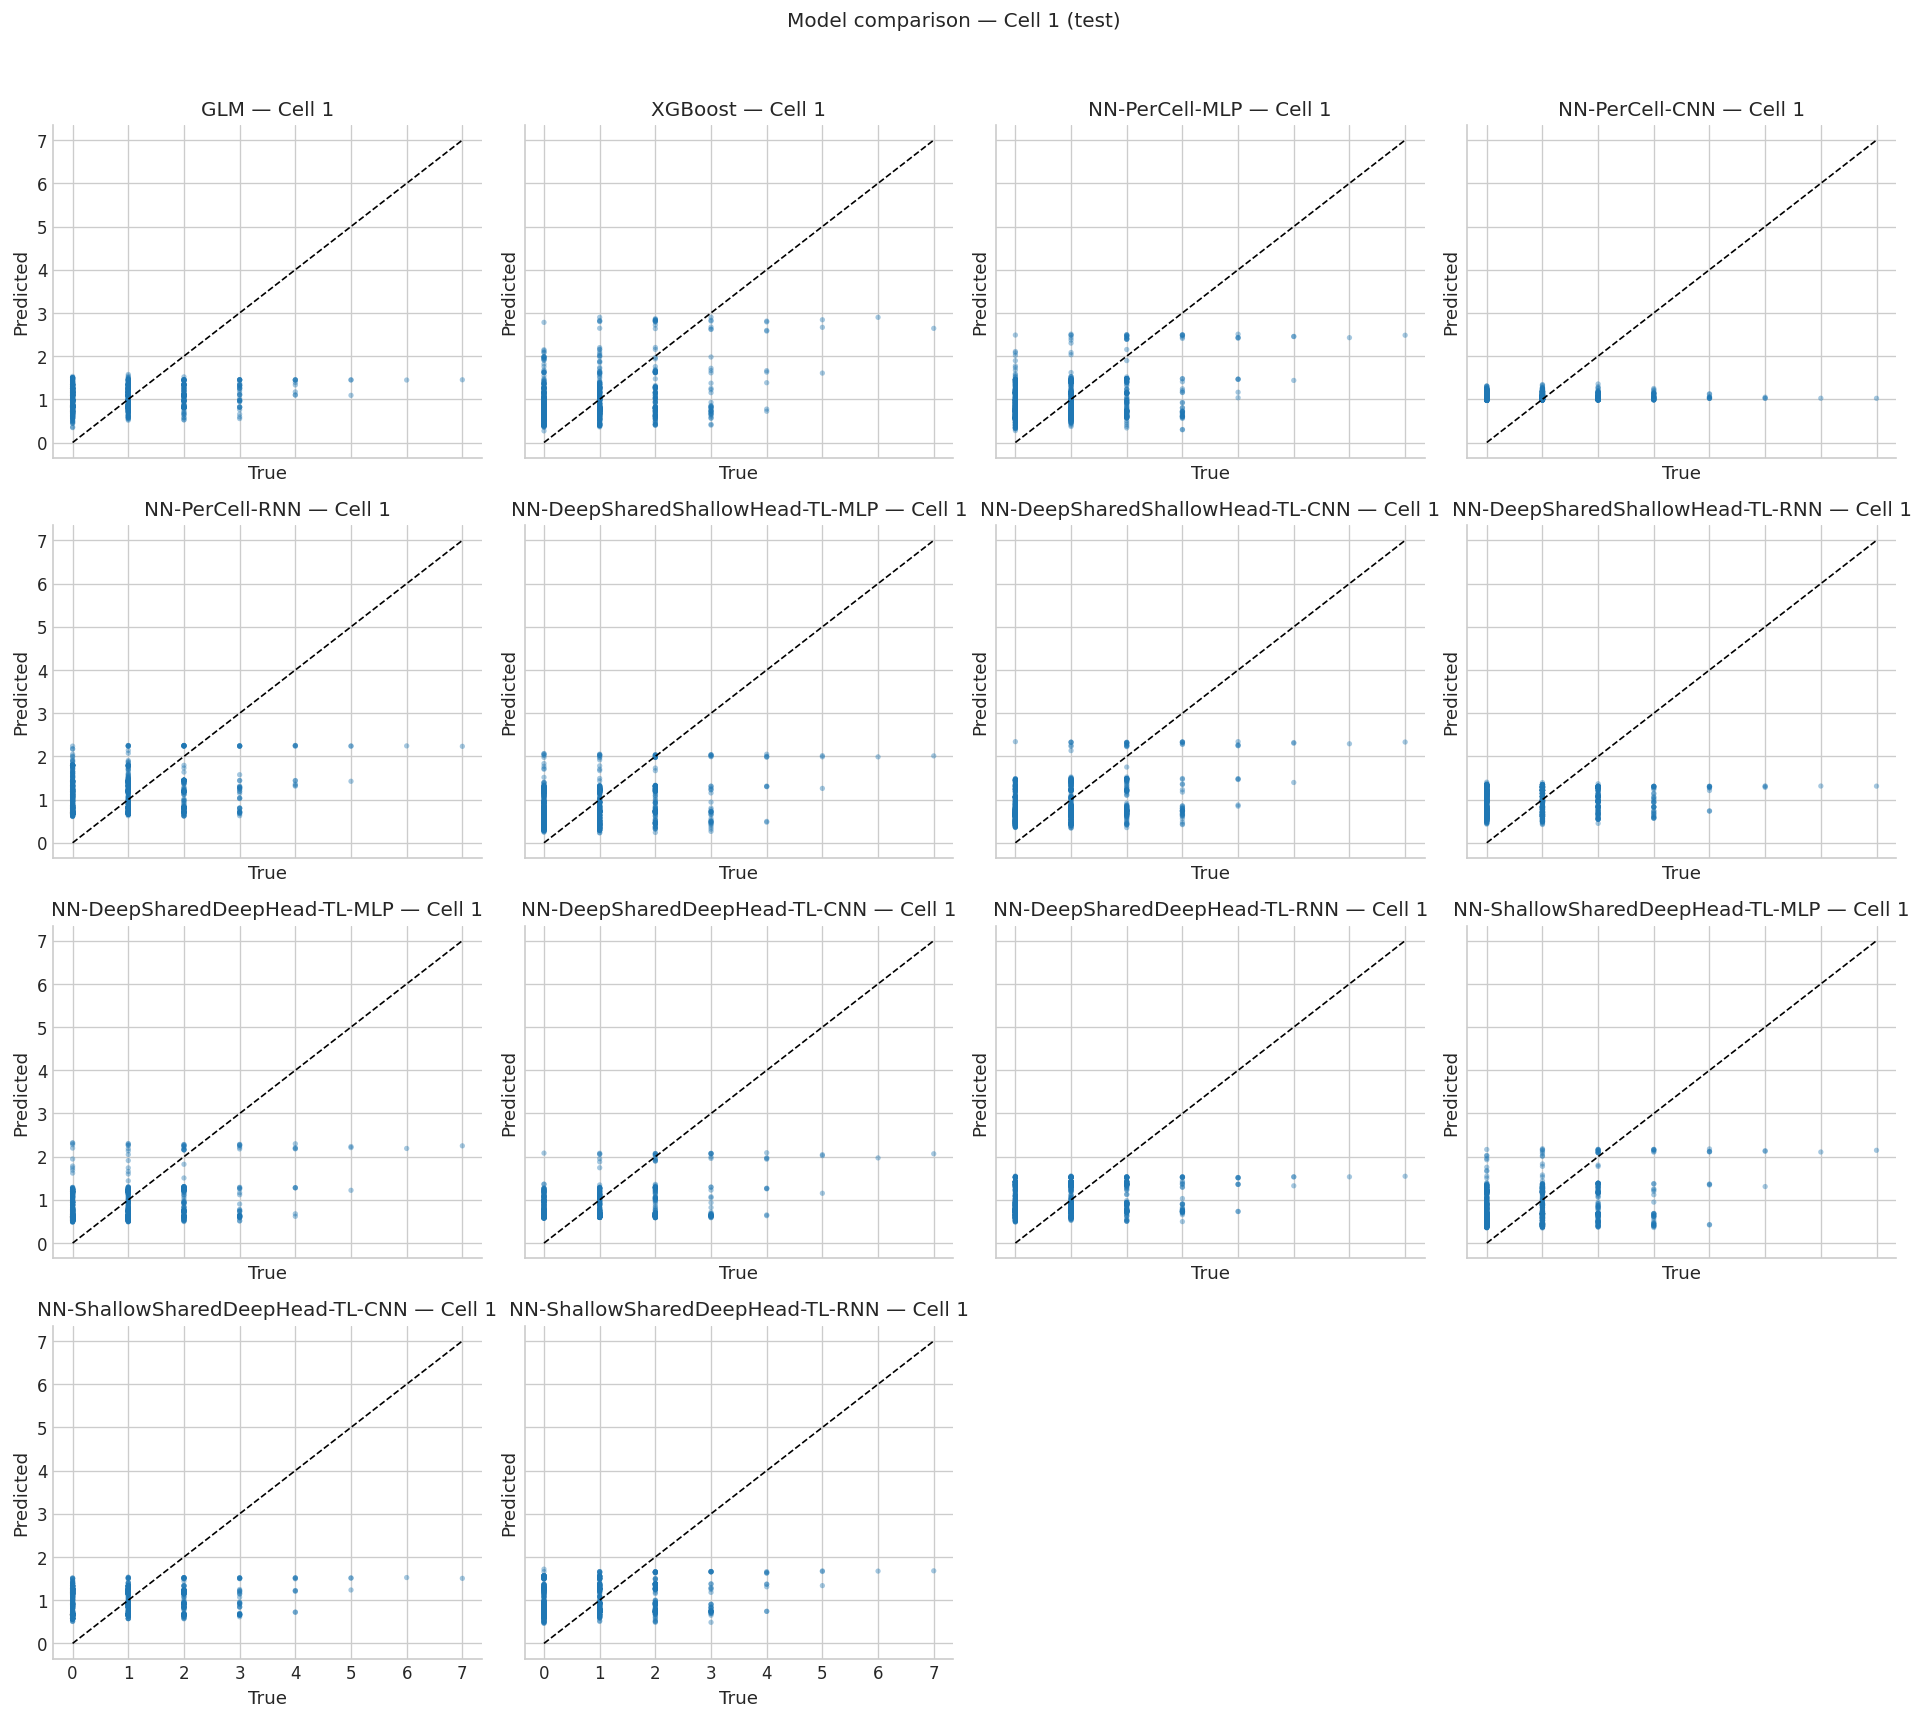

In [70]:
compare_models_for_cell(model_results_gs, cell=1, split="test")

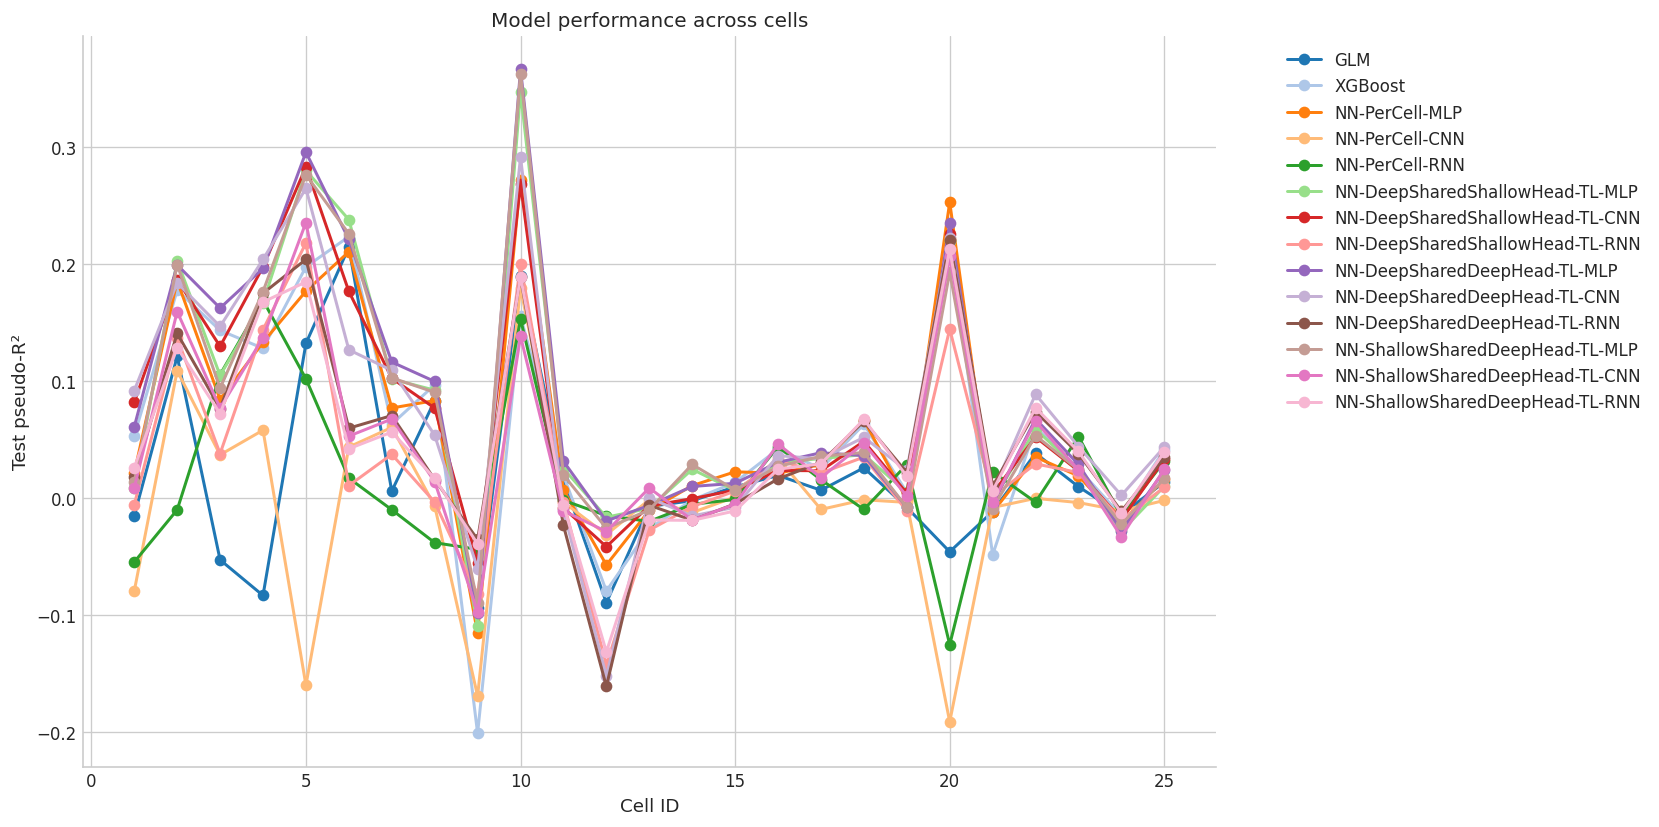

In [71]:
compare_r2_across_cells(model_results_gs, split="test")

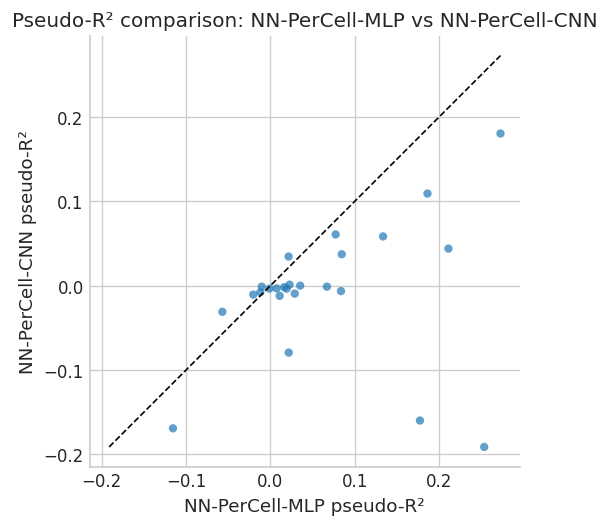

In [72]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [73]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
log_print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    log_print(f"  {p}")

Generated 117 plots
  ..\resources\results\real\batch_0\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\real\batch_0\journal\pairwise_NN-ShallowSharedDeepHead-TL-CNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
